In [1]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import yaml
import importlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter

plt.style.use('latex_default.mplstyle')

In [2]:
folder = "/work/bd0620/b309199/linear-mws"
# flavors = ["pmap_mpdata", "pmap_nx2048", "pmap_ny65", "pmap_nz1281", "pmap_amp100", "pmap_circle", "pmap_bcy1", "pmap_dy"]
flavors = ["pmap_ld", "pmap_amp100", "pmap_circle", "pmap_bcy1", "pmap_dy"]
# flavors = ["pmap_amp100"]

# flavors = ["pmap_mpdata", "pmap_nx2048", "pmap_ny65", "pmap_nz1281", "pmap_amp100"]

all_ds_lists = {}
all_cfgs = {}
print("Starting...")
for flavor in flavors:

    if flavor == "pmap_bcy1":
        sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", 
                f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", 
                f"{flavor}_MW_125km", f"{flavor}_MW_150km"]
        # sims = [f"{flavor}_MW_005km", f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km"]
    # elif flavor == "pmap_nz1281":
    #     sims = [f"{flavor}_MW_001km", f"{flavor}_MW_010km", f"{flavor}_MW_100km"] # 10km
    # elif flavor == "pmap_nx2048":
    #     sims = [f"{flavor}_MW_001km", f"{flavor}_MW_010km", f"{flavor}_MW_100km"]
    # elif flavor == "pmap_ny65":
    #     sims = [f"{flavor}_MW_100km"]
    elif flavor == "pmap_amp100":
        sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", 
                f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km",
                f"{flavor}_MW_125km", f"{flavor}_MW_150km"] # f"pmap_dz0_amp100_MW_100km"
    elif flavor == "pmap_dy":
        # sims = [f"{flavor}_MW_050km", f"{flavor}_MW_075km"]
        sims = [f"pmap_ld_MW_000km", f"pmap_ld_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km",
                f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", 
                f"{flavor}_MW_125km", f"{flavor}_MW_150km"]
    elif flavor == "pmap_circle":
        sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", 
                f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", 
                f"{flavor}_MW_125km", f"{flavor}_MW_150km"]
    elif flavor == "pmap_ld":
        sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", 
                f"{flavor}_MW_010km", f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", 
                f"{flavor}_MW_125km", f"{flavor}_MW_150km"]
        # sims = [f"{flavor}_MW_001km", f"{flavor}_MW_010km", f"{flavor}_MW_050km", f"{flavor}_MW_100km"]

    ds_list = []
    cfgs = []
    model = flavor.split("_")[0]
    # tstamp = 299
    tstamp = -2
    for sim in sims:
        fpath = os.path.join(folder, sim)
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=tstamp, slices={"x": 0, "y": 0, "z": [0]})
        cfgs.append(cfg)
        ds_list.append(ds)
    all_ds_lists[flavor] = ds_list
    all_cfgs[flavor] = cfgs
print("DONE")

Starting...
DONE


In [3]:
import mpmath

# --- Nondimensional Blumen (1965) drag for Witch-of-Agnesi, as a function of a ---
def blumen65_nd_for_a(a, U, N, f):
    """
    Nondimensional drag D* = D / (rho0 * U * N * h_0**2)
    for a 2D Witch-of-Agnesi ridge, using Fourier conv.  ĥ(k) = (1/2π)∫ h e^{-ikx} dx.
    """
    if not (a > 0 and U > 0 and 0 <= f < N):
        return np.nan

    mu   = U / (a * N)      # nonhydrostatic parameter
    beta = f * a / U        # rotation parameter

    kmin = beta
    kmax = 1.0 / mu
    if not (kmin < kmax):
        return 0.0  # no propagating waves

    # tiny padding away from endpoints
    eps_left  = 1e-12 * (1 + kmin)
    eps_right = 1e-12 * (1 + kmax)
    a1 = kmin + eps_left
    b1 = kmax - eps_right
    if a1 >= b1:
        return 0.0

    def integrand(kappa):
        if kappa == 0:
            return mpmath.mpf('0.0')
        nh_arg = 1.0 - (mu * kappa)**2
        nh_arg = nh_arg if nh_arg > 0 else 0.0
        if beta == 0.0:
            f_fac = 1.0
        else:
            f_arg = 1.0 - (beta / kappa)**2
            f_arg = f_arg if f_arg > 0 else 0.0
            f_fac = mpmath.sqrt(f_arg)
        return kappa * mpmath.e**(-2.0 * kappa) * mpmath.sqrt(nh_arg) * f_fac

    I_mid   = mpmath.quad(integrand, [a1, b1])
    I_left  = mpmath.quad(integrand, [kmin, a1])
    I_right = mpmath.quad(integrand, [b1, kmax])

    I = I_left + I_mid + I_right

    # Correct prefactor to achieve D* → π/4 in the (β=0, μ→0) limit
    Dstar = mpmath.pi * I
    return float(mpmath.re(Dstar))


# --- New: Nonhydrostatic, nonrotating approximation (f = 0) ---
def blumen65_nonhydro_nd_for_a(a, U, N):
    """
    Nondimensional drag D* in the nonhydrostatic, nonrotating limit (f=0).
    D* = π ∫_{0}^{1/μ} κ e^{-2κ} sqrt(1 - μ^2 κ^2) dκ,  with μ = U/(a N).
    """
    if not (a > 0 and U > 0 and N > 0):
        return np.nan

    mu = U / (a * N)    # nonhydrostatic parameter
    kmin, kmax = 0.0, 1.0 / mu
    if not (kmin < kmax):
        return 0.0

    # tiny padding from the right endpoint where sqrt→0
    eps_right = 1e-12 * (1 + kmax)
    b1 = kmax - eps_right
    if b1 <= 0:
        return 0.0

    def integrand(kappa):
        nh_arg = 1.0 - (mu * kappa)**2
        nh_arg = nh_arg if nh_arg > 0 else 0.0
        return kappa * mpmath.e**(-2.0 * kappa) * mpmath.sqrt(nh_arg)

    I = (mpmath.quad(integrand, [0.0, b1]) +
         mpmath.quad(integrand, [b1, kmax]))
    return float(mpmath.pi * I)


# Parameters for Smith
a = 1e-5                                     # since 10^(-10) = a^2
# L_vals = np.linspace(1000.0, 100000.0, 100)  # 100 points (linear grid)
L_vals = np.geomspace(100, 300000, 300)

# Closed-form integral for ∫_a^∞ sqrt(k^2 - a^2) * exp(-2 L k) dk
# I(L) = (a / (2 L)) * K1(2 a L)
def I_a_to_inf(L):
    return (a / (2.0 * L)) * mpmath.besselk(1, 2.0 * a * L)

U = 10.0      # m/s
N = 0.01      # 1/s
f = 1.0e-4    # 1/s

# If you need to build it: choose an a-grid (here log-spaced 0.5–100 km)
smith79 = np.pi * (L_vals**2) * np.array([I_a_to_inf(L) for L in L_vals], dtype=float)
blumen65_nh = np.array([blumen65_nonhydro_nd_for_a(L, U, N) for L in L_vals])
blumen65 = np.array([blumen65_nd_for_a(L, U, N, f) for L in L_vals])

# Pack results
dfana = pd.DataFrame({
    "L": L_vals,
    "Smith79": smith79,
    "Blumen65_nh": blumen65_nh,
    "Blumen65": blumen65
})

# Save to CSV (optional)
# dfana.to_csv("dfana.csv", index=False)
# print("Saved to integral_results_L_100pts.csv")

# Quick peek
print(dfana.tail())

                 L   Smith79  Blumen65_nh  Blumen65
295  269528.430538  0.011108     0.785390  0.011108
296  276843.129837  0.009711     0.785390  0.009710
297  284356.341870  0.008456     0.785391  0.008455
298  292073.454050  0.007333     0.785391  0.007332
299  300000.000000  0.006333     0.785392  0.006333


stb00: 1.0200000360782724e-05
N: 0.010001141698024647
U: 10.0
rho00: 1.0
AMP: 10.0
f: 0.0001000012192610125
Drag_0: 10.001141698024647
---- pmap_ld ----
---- pmap_amp100 ----
L 0.5000570849012324, (ang-gwd): -2.4158198106806914%
L 1.0001141698024647, (ang-gwd): -0.6923786238424483%
L 2.0002283396049294, (ang-gwd): 0.38723522675937944%
L 3.000342509407394, (ang-gwd): 0.854499946661203%
L 5.000570849012323, (ang-gwd): 1.2798661142757521%
L 10.001141698024647, (ang-gwd): 1.6059753783435289%
L 25.002854245061616, (ang-gwd): 3.0454351158121677%
L 50.00570849012323, (ang-gwd): 5.050730732940294%
L 75.00856273518485, (ang-gwd): 7.0729645361943705%
L 100.01141698024647, (ang-gwd): 8.511514696439622%
L 125.01427122530808, (ang-gwd): 10.059492102885219%
L 150.0171254703697, (ang-gwd): 10.789196718971402%
---- pmap_circle ----
L 0.5000570849012324: 42.67765997034908%
L 1.0001141698024647: 29.708212422584996%
L 2.0002283396049294: 21.505874378343357%
L 3.000342509407394: 19.38369193733866%
L 5.000

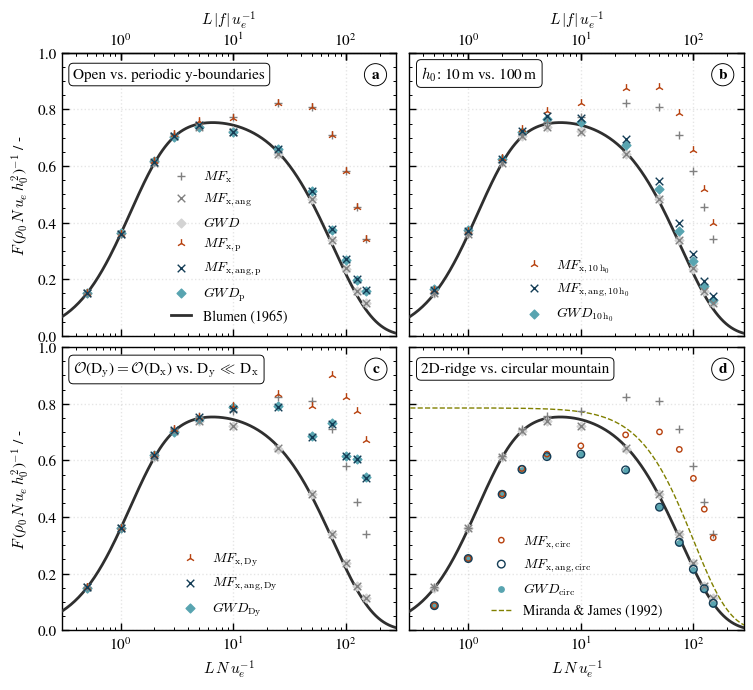

In [8]:
gskw  = {'hspace':0.04, 'wspace':0.04, 'width_ratios': [1,1]}
fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8.8,7.5), gridspec_kw=gskw)
ax0 = axes[0,0]
ax1 = axes[0,1]
ax2 = axes[1,0]
ax3 = axes[1,1]

# axes[-1].axis('off')

color_palette = [
        "#D72638",  # Crimson Red - Primary
        "#F46036",  # Coral Orange - Accent
        "#F6AE2D",  # Golden Sand - Highlight
        "mediumorchid",  # Teal Green - Complementary
        "#2F2F2F",  # Charcoal Gray - Neutral Base
        "grey",  # Mist White - Light Neutral
        "#58A4B0",  # Sky Blue - Cool Accent
        "#133C55"   # Midnight Blue - Deep Shade
    ]
    
c1 = color_palette[-1]
c2 = color_palette[-2] # 'mediumorchid'
c3 = "#B7410E" # color_palette[0]
c4 = color_palette[3]
lw_cross = 1
lwall = 1
lw_thick = 6

marks = ["D", "x", "+", "2"]

U = cfg['ambient_fields']['velocity_x']
grav = cfg['constants']['gravity0']
stb00 = cfg['ambient_fields']['stb00']
N = np.sqrt(stb00*grav)
rho00 = cfg['ambient_fields']['rho00']
AMP = cfg['define_orography']['args']['amplitude']
f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)

print(f"stb00: {stb00}")
print(f"N: {N}")
print(f"U: {U}")
print(f"rho00: {rho00}")
print(f"AMP: {AMP}")
print(f"f: {f}")

# N=0.01
# U=10
# f=10**(-4)
drag0 = rho00*U*N*AMP**2
print(f'Drag_0: {drag0}')

# - Linear theory: Smith - #
# a = 0.63*U/f
# smith_x = a * N / U
# smith = 0.5 * theoretical_max # drag dropped to half for af/U = 0.63 -> a = 63km
# smith_x = 30000 * N / U
# smith = 0.8*np.pi/4 # af/U = 1 -> a = 100km
# ax0.scatter(smith_x, smith, marker='o', s=50, color='darkorchid', alpha=0.6, lw=lw_cross)
        
# - Linear Theory: Miranda and James for large L - #
# XML = np.logspace(1,10,100)
XML = np.linspace(1,500000,300)
# print(XML)
XVALUES = XML * N / U
mirandaJames = np.pi/4 * (1+2*f*XML/U)*np.exp(-2*f*XML/U)
mirandaJames2 = np.pi/4 * XML * (1+2*f*XML/U)*np.exp(-2*f*XML/U)
# ax0.plot(XVALUES,mirandaJames*XML, color='darkgoldenrod', alpha=0.6, lw=2, ls='--', label=r"Miranda and James 1992")

abs_factor = 1
z = 0
j = 0

angMom_ref = []
for flavor, ds_list in all_ds_lists.items():     
    cfgs = all_cfgs[flavor]
    model = flavor.split("_")[0]
    print("----", flavor, "----")
    for i, ds in enumerate(ds_list):
        cfg = cfgs[i]
        L = cfg['define_orography']['args']['halfwidth']
        AMP = cfg['define_orography']['args']['amplitude']
        x_regime = L * N / U
        
        if cfg['absorber']['xboundaries']:
            nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
            nrelax1 = cfg['nx'] - nrelax0
        else:
            nrelax0 = 0
            nrelax1 = cfg['nx']
        
        zs = ds['zcr'][0,:].values
        dzdx_surf = np.gradient(zs, cfg['dx'], axis=0)
        pprime = ds['pprime']
        # print(ds.variables)
        try: 
            uprime = ds['u'] - U
        except:
            print("Failed: ", flavor, L)
            continue
        vprime = ds['v']
        wprime = ds['w']
        rhoprime = ds['rhoprime']
        # rho = ds['density']
        # rho0 = ds['rho0']
        # th = ds['theta_total']
        # thprime = ds['thprime']
        xcr = ds.x[nrelax0:nrelax1]
        
        # - Drag from pressure perturbation - #
        drag = integrate.trapezoid(pprime[z,nrelax0:nrelax1] * dzdx_surf[nrelax0:nrelax1], xcr) # 0.3576
        # drag = integrate.simps(ds.pprime[12,z,y,:] * ds.dzdx_surf[y,:], 1000*ds.xcr[y,:])
    
        # - Drag from vertical flux of angular momentum (vertical momentum flux + streamwise Coriolis force) - # 
        drag_vertMom = -rho00* integrate.trapezoid(uprime[z,nrelax0:nrelax1] * wprime[z,nrelax0:nrelax1], xcr)
        drag_f = -f * rho00 * integrate.trapezoid(vprime[z,nrelax0:nrelax1] * zs[nrelax0:nrelax1], xcr)
        # drag_vertMom_v = -ds['rh0'][0,z,0,0]*integrate.trapezoid((ds.v[z,y,n_sponge:ds.nx-n_sponge]-ds.ve[z,y,n_sponge:ds.nx-n_sponge])*ds.w[z,y,n_sponge:ds.nx-n_sponge], 1000.*ds.xcr[y,n_sponge:ds.nx-n_sponge])
        
        # - Drag from compressible effects (rho') - #
        # thloc = ds['the'][z,y,n_sponge:ds.nx-n_sponge] + ds['th'][z,y,n_sponge:ds.nx-n_sponge] # Theta
        # tloc = thloc*(ds['pr0'][z,y,n_sponge:ds.nx-n_sponge]/ds['pref00'])**ds.cap # T
        # tte = ds['the'][z,:,:]*(ds['pr0'][z,:,:]/ds['pref00'])**ds.cap # T_env
        # ploc = ds['pprime'][z,y,n_sponge:ds.nx-n_sponge]+ds['pr0'][z,y,n_sponge:ds.nx-n_sponge]
        # rholoc = ploc/(ds.rg*tloc)
    
        drag_comp = -f * integrate.trapezoid(rhoprime[z,nrelax0:nrelax1] * vprime[z,nrelax0:nrelax1] * zs[nrelax0:nrelax1], xcr)
            
        # - Normalized drag - #
        drag0 = rho00*U*N*AMP**2
        drag         = drag         / drag0
        drag_vertMom = drag_vertMom / drag0
        drag_f       = drag_f       / drag0
        drag_comp    = drag_comp    / drag0
    
        drag_angMom  = drag_vertMom + drag_f
        # drag_angMom  = drag_vertMom + drag_f + drag_comp # drag_vertMom_v
        # print(f"L: {L}, Drag: {drag}, Drag_vertMom: {drag_vertMom}, Drag_compressible: {drag_comp}")
    
        a1 = 1
        ss  = 30
        ss1 = 40
        ss2 = 20

        if flavor == "pmap_bcy1":
            print(f"L {x_regime}: {(angMom_ref[i]-drag_angMom)/angMom_ref[i]*100}%")
            if i == 0:
                ax0.scatter(x_regime, drag_vertMom, marker="2", s=ss1, color=c3, alpha=a1, lw=lw_cross, zorder=10, label=r'$MF_\mathrm{x,p}$')
                ax0.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10, label=r'$MF_\mathrm{x,ang,p}$')
                ax0.scatter(x_regime, drag, marker=marks[0], s=ss2, color=c2, alpha=a1, lw=lw_cross, zorder=9, label=r'$GWD_\mathrm{p}$')
            else:
                ax0.scatter(x_regime, drag_vertMom, marker="2", s=ss1, color=c3, alpha=a1, lw=lw_cross, zorder=10)
                ax0.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10)
                ax0.scatter(x_regime, drag, marker=marks[0], s=ss2, color=c2, alpha=a1, lw=lw_cross, zorder=9)
        elif flavor == "pmap_dy":
            if i == 0:
                ax2.scatter(x_regime, drag_vertMom, marker="2", s=ss1, color=c3, alpha=a1, lw=lw_cross, zorder=10, label=r'$MF_\mathrm{x,Dy}$')
                ax2.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10, label=r'$MF_\mathrm{x,ang,Dy}$')
                ax2.scatter(x_regime, drag, marker=marks[0], s=ss2, color=c2, alpha=a1, lw=lw_cross, zorder=9, label=r'$GWD_\mathrm{Dy}$')
            else:
                ax2.scatter(x_regime, drag_vertMom, marker="2", s=ss1, color=c3, alpha=a1, lw=lw_cross, zorder=10)
                ax2.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10)
                ax2.scatter(x_regime, drag, marker=marks[0], s=ss2, color=c2, alpha=a1, lw=lw_cross, zorder=9)
        elif flavor == "pmap_amp100":
            # vari = np.mean(np.sqrt(uprime[z,nrelax0:nrelax1].values**2)) / 10
            vari = np.mean(np.sqrt(wprime[z,nrelax0:nrelax1].values**2)) / 10
            # print(f"L {x_regime}: {vari}")

            print(f"L {x_regime}, (ang-gwd): {(drag_angMom-drag)/drag_angMom*100}%")
            # print(f"L {x_regime}: {(angMom_ref[i]-drag_angMom)/angMom_ref[i]*100}%")
            
            dpdx = pprime.differentiate("x")          # Pa / m (assumes x coordinate in meters)
            pgf_x = -(1.0 / rho00) * dpdx            # m / s^2
            cor_x = f * vprime                          # m / s^2
            
            # 7) Imbalance and normalized imbalance
            imbalance = cor_x - pgf_x
            # print(f"L {x_regime}: {np.mean(imbalance.values[z,nrelax0:nrelax1])}")
            
            den = xr.ufuncs.maximum(xr.ufuncs.fabs(cor_x), xr.ufuncs.fabs(pgf_x))
            eps = imbalance / xr.where(den > 0, den, np.nan)
            # print(f"L {x_regime}: {np.mean(eps.values[z,nrelax0:nrelax1])}")
            
            if i==0:
                ax1.scatter(x_regime, drag_vertMom, marker="2", s=ss1, color=c3, alpha=a1, lw=lw_cross, zorder=10, label=r'$MF_\mathrm{x,10\,h_0}$')
                ax1.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10, label=r"$MF_\mathrm{x,ang,10\,h_0}$")
                ax1.scatter(x_regime, drag, marker=marks[0], s=ss2, color=c2, alpha=a1, lw=lw_cross, zorder=9, label=r"$GWD_\mathrm{10\,h_0}$")
            else:
                ax1.scatter(x_regime, drag_vertMom, marker="2", s=ss1, color=c3, alpha=a1, lw=lw_cross, zorder=10)
                ax1.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10)
                ax1.scatter(x_regime, drag, marker=marks[0], s=ss2, color=c2, alpha=a1, lw=lw_cross, zorder=9)
        elif flavor == "pmap_circle":
            print(f"L {x_regime}: {(angMom_ref[i]-drag_angMom)/angMom_ref[i]*100}%")
            if i == 0:
                ax3.scatter(x_regime, drag_vertMom, marker='o', facecolor='none', s=ss-15, edgecolor=c3, alpha=a1, lw=lw_cross, zorder=10, label=r"$MF_\mathrm{x,circ}$")
                ax3.scatter(x_regime, drag_angMom, marker='o', facecolor='none', s=ss, edgecolor=c1, alpha=a1, lw=lw_cross, zorder=10, label=r"$MF_\mathrm{x,ang,circ}$")
                ax3.scatter(x_regime, drag, marker='o', facecolor=c2, s=ss-15, edgecolor=c2, alpha=a1, lw=lw_cross, zorder=9, label=r'$GWD_\mathrm{circ}$')
            else:
                ax3.scatter(x_regime, drag_vertMom, marker='o', facecolor='none', s=ss-15, edgecolor=c3, alpha=a1, lw=lw_cross, zorder=10)
                ax3.scatter(x_regime, drag_angMom, marker='o', facecolor='none', s=ss, edgecolor=c1, alpha=a1, lw=lw_cross, zorder=10)
                ax3.scatter(x_regime, drag, marker='o', facecolor=c2, s=ss-15, edgecolor=c2, alpha=a1, lw=lw_cross, zorder=9)
        elif flavor == "pmap_ld":
            angMom_ref.append(drag_angMom)
            # vari = np.mean(np.sqrt(uprime[z,nrelax0:nrelax1].values**2)) / 10
            # vari = np.mean(np.sqrt(uprime[z,512:-512].values**2)) / 10
            # print(f"L {x_regime}: {vari}")
            dpdx = pprime.differentiate("x")          # Pa / m (assumes x coordinate in meters)
            pgf_x = -(1.0 / rho00) * dpdx            # m / s^2
            cor_x = f * vprime                          # m / s^2
            
            # 7) Imbalance and normalized imbalance
            imbalance = cor_x - pgf_x
           # print(f"L {x_regime}: {np.mean(imbalance.values[z,nrelax0:nrelax1])}")
            
            for ax in axes.flatten():
                if i == 0 and ax == ax0:
                    ax.scatter(x_regime, drag_vertMom, marker=marks[2], s=ss1, color='grey', alpha=a1, lw=lw_cross, zorder=10, label=r'$MF_\mathrm{x}$')
                    ax.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color='grey', alpha=a1, lw=lw_cross, zorder=10, label=r'$MF_\mathrm{x,ang}$')
                    ax.scatter(x_regime, drag, marker=marks[0], s=ss2, color='lightgrey', alpha=a1, lw=lw_cross, zorder=9, label=r'$GWD$')
                else:
                    ax.scatter(x_regime, drag_vertMom, marker=marks[2], s=ss1, color='grey', alpha=a1, lw=lw_cross, zorder=10)
                    ax.scatter(x_regime, drag_angMom, marker=marks[1], s=ss, color='grey', alpha=a1, lw=lw_cross, zorder=10)
                    ax.scatter(x_regime, drag, marker=marks[0], s=ss2, color='lightgrey', alpha=a1, lw=lw_cross, zorder=9)
        # elif flavor=="pmap_nx2048":
        #     if i == 0:
        #         ax0.scatter(x_regime, drag_angMom, marker=marks[2], s=ss+40, color='coral', alpha=a1, lw=lw_cross, zorder=10, label=flavor_labels[j])
        #     else:
        #         ax0.scatter(x_regime, drag_angMom, marker=marks[2], s=ss+40, color='coral', alpha=a1, lw=lw_cross, zorder=10)
        # elif flavor=="pmap_ny65":
        #     ax0.scatter(x_regime, drag_angMom, marker=marks[2], s=ss+20, color=c2, alpha=a1, lw=lw_cross, zorder=10, label=flavor_labels[j])
        # elif flavor=="pmap_nz1281":
        #     if i == 0:
        #         ax0.scatter(x_regime, drag_angMom, marker="2", s=ss+20, color=c3, alpha=a1, lw=lw_cross, zorder=10, label=flavor_labels[j])
        #     else:
        #         ax0.scatter(x_regime, drag_angMom, marker="2", s=ss+20, color=c3, alpha=a1, lw=lw_cross, zorder=10)

    # if j > 0:
    #     ax0d.plot(xregimes, diff_drag)
    #     ax1d.plot(xregimes, diff_amom)
    j += 1
    
for ax in axes.flatten():
    if ax == ax0:
        ax.plot(dfana['L']/1000,dfana['Blumen65'], color="#2F2F2F", lw=lwall+1, ls="-", zorder=5, label="Blumen (1965)")
    else:
        ax.plot(dfana['L']/1000,dfana['Blumen65'], color="#2F2F2F", lw=lwall+1, ls="-", zorder=5)
    # ax.plot(dfana['L']/1000,dfana['Blumen65_nh'], color="#E2725B", lw=lwall, ls="--")
    # ax.plot(dfana['L']/1000,dfana['Smith79'], color="#F6AE2D", lw=lwall, ls="--")
    if ax == ax3:
        ax.plot(XVALUES,mirandaJames, color="#808000", lw=lwall, ls='--', zorder=5, label="Miranda & James (1992)")

# - Formatting and saving - #
xtick_labels_top = ['xx','xx','0.01','0.1','1','xx']

numstr = ['a','b','c','d']
ax_labels = [r"Open vs. periodic y-boundaries", r"$h_0$: 10$\,$m vs. 100$\,$m", r"$\mathcal{O}$(D$_\mathrm{y}$)$=\mathcal{O}$(D$_\mathrm{x}$) vs. D$_\mathrm{y}\, \ll \,$D$_\mathrm{x}$", r"2D-ridge vs. circular mountain"]
# ($\Delta$y$\,=\, \Delta$x)
for i, ax in enumerate(axes.flatten()):
    ax.text(0.035, 0.91, ax_labels[i], transform=ax.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.text(0.95, 0.91, numstr[i], transform=ax.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.grid()
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.legend(handlelength=1.5, loc='lower center', frameon=False, fontsize=10)

    if i < 2:
        ax_t = ax.secondary_xaxis('top')
        xticks = ax_t.get_xticks()
        ax_t.set_xticks(xticks)
        ax_t.set_xticklabels(xtick_labels_top)
        ax_t.set_xlabel(r"$L \, |f| \, u_e^{-1}$")
        ax_t.tick_params(which='both', labelright=False)
        
ax0.set_ylim([0,1])
ax0.set_xlim([3*10**(-1),2.8*10**(2)])
ax0.xaxis.set_minor_locator(AutoMinorLocator(5))
ax0.yaxis.set_minor_locator(AutoMinorLocator())
ax0.set_xscale('log')
ax0.set_ylabel(r'$F\,$($\rho_0 \, N \, u_e \, h_0^2$)$^{-1}$ / -')
ax2.set_ylabel(r'$F\,$($\rho_0 \, N \, u_e \, h_0^2$)$^{-1}$ / -')
ax2.set_xlabel(r'$L\,N\,u_e^{-1}$')
ax3.set_xlabel(r'$L\,N\,u_e^{-1}$')

# ax0.xaxis.set_minor_locator(AutoMinorLocator())
# ax1.tick_params(which='both', labelright=True)
# ax_t.xaxis.set_minor_locator(AutoMinorLocator())

# fig.tight_layout()
fig_title = f"surface_gwd_sensitivity_temp.png"
fig.savefig('../data/pmap/' + fig_title, facecolor='w', edgecolor='w',
                format='png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
"""Notes"""
cfg['ambient_fields']['velocity_x']
cfg['define_orography']['args']
cfg['constants']['fcoriolis0']
cfg['constants']['angle0']